# ESC50 Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the ESC-50 dataset.

**Objectives:**
- Compare S4 vs LMU performance across different data sizes
- Analyze data efficiency (which model learns better with less data)
- Visualize learning curves and test metrics
- Identify the best model/fraction combination

**Fractions tested:** 10%, 25%, 50%, 100%


In [2]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

compare_folder = Path("figs")
compare_folder.mkdir(exist_ok=True)

print(f"Project root: {project_root}")

Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4


## Load Test Results

Load test_results.json from each run folder for both S4 and LMU models across all data fractions.


In [3]:
from src.eval.compare import load_all_experiments

# Configuration
base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "esc50"

print("="*60)
print("LOADING ESC-50 EXPERIMENT RESULTS")
print("="*60)
print()

# Load all results
all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

# Quick summary
for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")



CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


LOADING ESC-50 EXPERIMENT RESULTS

Loading S4 @ 10%: esc50_s4_task_frac_10
Loading S4 @ 25%: esc50_s4_task_frac_25
Loading S4 @ 50%: esc50_s4_task_frac_50
Loading S4 @ 100%: esc50_s4_task
Loading LMU @ 10%: esc50_lmu_task_frac_10
Loading LMU @ 25%: esc50_lmu_task_frac_25
Loading LMU @ 50%: esc50_lmu_task_frac_50
Loading LMU @ 100%: esc50_lmu_task

LOADING COMPLETE
S4: Loaded 4/4 experiments
LMU: Loaded 4/4 experiments


## Results Summary Table


In [4]:
from src.eval.compare import create_test_comparison_table

print()

test_comparison_df = create_test_comparison_table(
    all_results,
    metrics=['accuracy', 'loss']
)

pd.options.display.float_format = '{:.3f}'.format

test_comparison_df['fraction'] = test_comparison_df['data_pct'] / 100
pivot_acc = test_comparison_df.pivot(index='fraction', columns='model', values='accuracy')
pivot_loss = test_comparison_df.pivot(index='fraction', columns='model', values='loss')

print("\nTest Accuracy by Model and Data Fraction:")
print(pivot_acc)
print("\nTest Loss by Model and Data Fraction:")
print(pivot_loss)

if 'S4' in pivot_acc.columns and 'LMU' in pivot_acc.columns:
    pivot_acc['LMU_vs_S4'] = ((pivot_acc['LMU'] - pivot_acc['S4']) * 100).round(2)
    print("\nLMU vs S4 Accuracy Difference:")
    print(pivot_acc['LMU_vs_S4'])

print("\n" + "="*60)
print("BEST MODEL PER DATA FRACTION")
print("="*60)

for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['accuracy'].idxmax()  # Higher is better for accuracy
    best_row = subset.loc[best_idx]
    print(f"\n{pct}% data: {best_row['model']} (Accuracy: {best_row['accuracy']*100:.2f}%)")

test_comparison_df



Test Accuracy by Model and Data Fraction:
model      LMU    S4
fraction            
0.100    0.123 0.145
0.250    0.205 0.257
0.500    0.385 0.440
1.000    0.495 0.560

Test Loss by Model and Data Fraction:
model      LMU    S4
fraction            
0.100    3.617 3.738
0.250    3.261 3.308
0.500    2.773 2.713
1.000    2.470 2.179

LMU vs S4 Accuracy Difference:
fraction
0.100   -2.250
0.250   -5.250
0.500   -5.500
1.000   -6.500
Name: LMU_vs_S4, dtype: float64

BEST MODEL PER DATA FRACTION

10% data: S4 (Accuracy: 14.50%)

25% data: S4 (Accuracy: 25.75%)

50% data: S4 (Accuracy: 44.00%)

100% data: S4 (Accuracy: 56.00%)


,model,data_pct,accuracy,loss,num_samples,fraction
0,LMU,10,0.123,3.617,400,0.100
1,LMU,25,0.205,3.261,400,0.250
2,LMU,50,0.385,2.773,400,0.500
3,LMU,100,0.495,2.470,400,1.000
4,S4,10,0.145,3.738,400,0.100
5,S4,25,0.257,3.308,400,0.250
6,S4,50,0.440,2.713,400,0.500
7,S4,100,0.560,2.179,400,1.000


## Visualization: Test Accuracy Comparison

Compare test accuracy of S4 and LMU across different data fractions.


Plot saved to: figs/test_data_efficiency.png


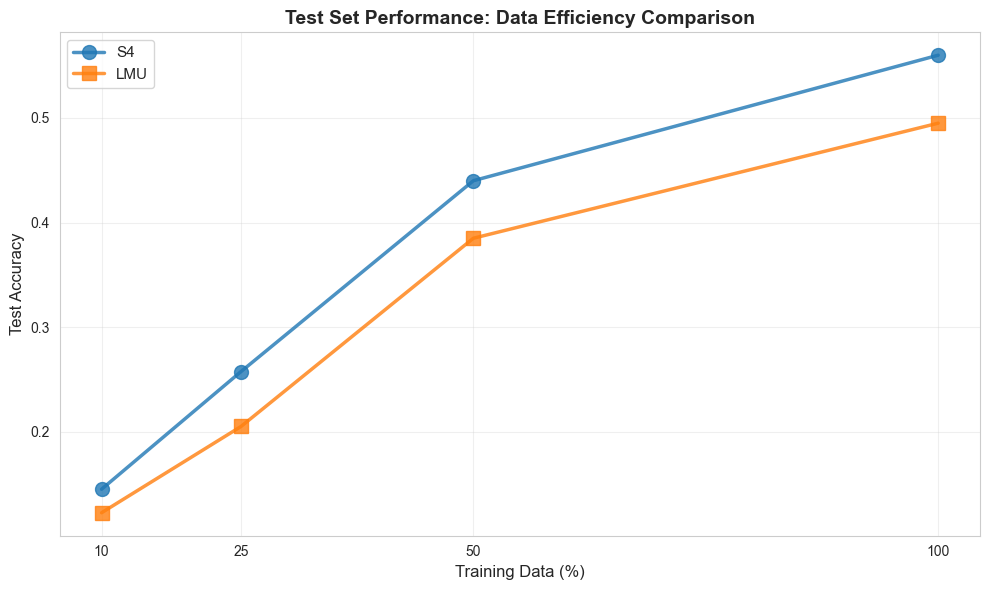

In [5]:
from src.eval.compare import plot_test_data_efficiency

plot_test_data_efficiency(
    all_results,
    metric_key='accuracy',
    ylabel='Test Accuracy',
    save_path=str(compare_folder / 'test_data_efficiency.png')
)


## Visualization: Test Loss Comparison

Compare test loss of S4 and LMU across different data fractions.


Plot saved to: figs/test_loss_comparison.png


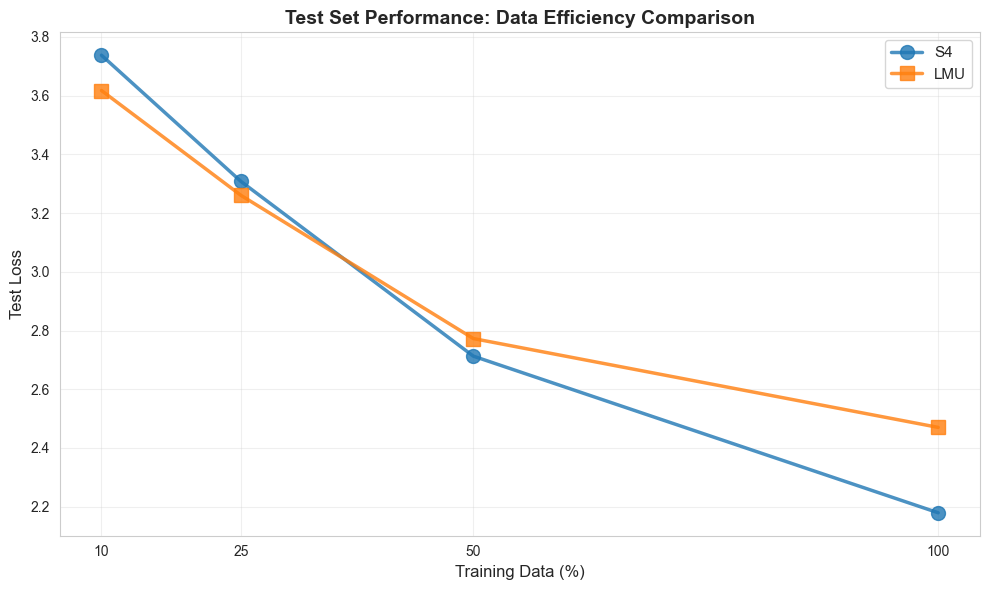

In [6]:
plot_test_data_efficiency(
    all_results,
    metric_key='loss',
    ylabel='Test Loss',
    save_path=str(compare_folder / 'test_loss_comparison.png')
)

## Bar Chart Comparison

Side-by-side comparison of test accuracy for each data fraction.


Plot saved to: figs/test_accuracy_comparison.png


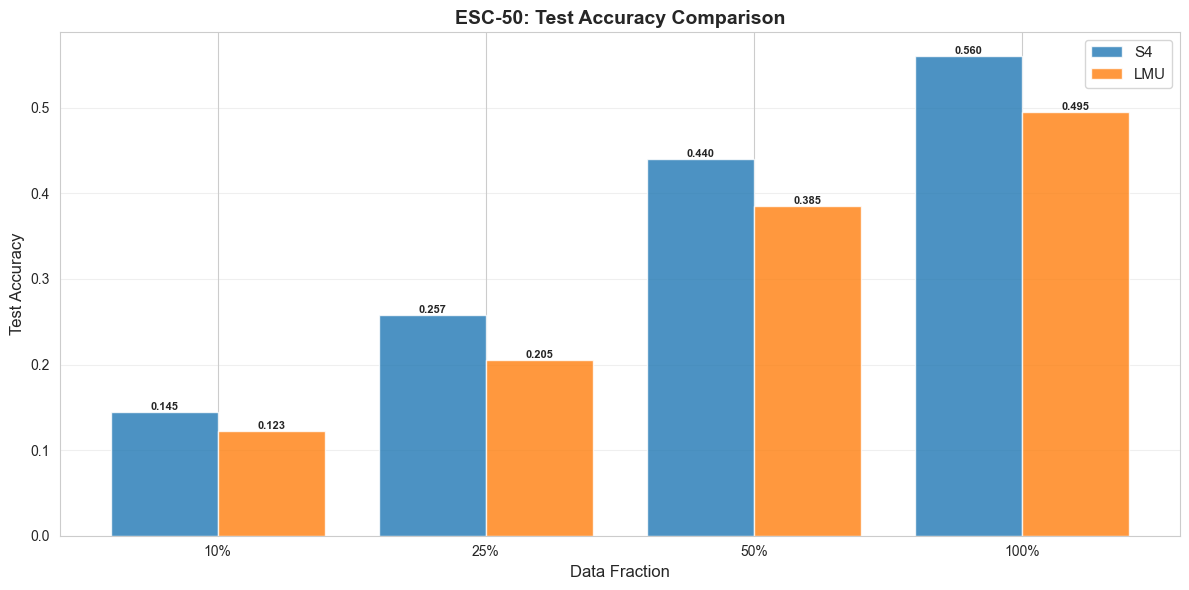

In [7]:
from src.eval.compare import plot_test_metric_comparison

plot_test_metric_comparison(
    all_results,
    metric_key='accuracy',
    title='ESC-50: Test Accuracy Comparison',
    ylabel='Test Accuracy',
    save_path=str(compare_folder / 'test_accuracy_comparison.png')
)

## Test Performance Heatmaps

Visual comparison of test set performance across models and data fractions.


Plot saved to: figs/test_performance_heatmap.png


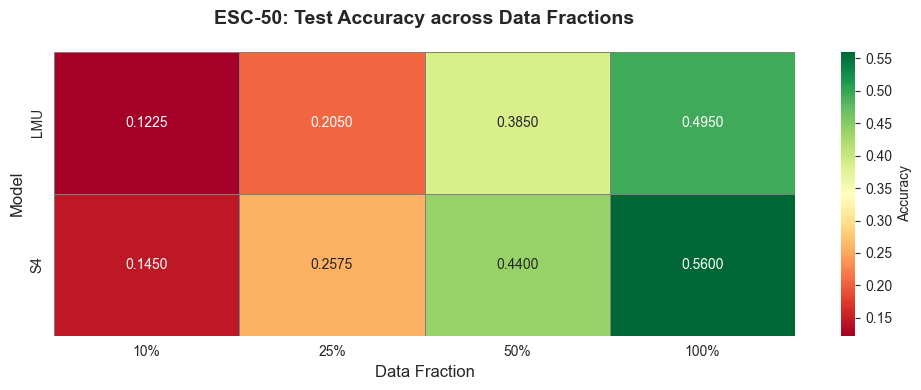

In [8]:
from src.eval.compare import plot_performance_heatmap

plot_performance_heatmap(
    all_results,
    metric_key='accuracy',
    title='ESC-50: Test Accuracy across Data Fractions',
    annot_format='.4f',
    save_path=str(compare_folder / 'test_performance_heatmap.png')
)

## Summary Statistics

Key insights from the comparison.


In [10]:
print("=" * 60)
print("ESC-50 MODEL COMPARISON SUMMARY")
print("=" * 60)
print()

# Best overall performance
best_overall = test_comparison_df.loc[test_comparison_df['accuracy'].idxmax()]
print(f"Best Overall Performance:")
print(f"  Model: {best_overall['model']}")
print(f"  Data Fraction: {int(best_overall['fraction']*100)}%")
print(f"  Accuracy: {best_overall['accuracy']*100:.2f}%")
print(f"  Loss: {best_overall['loss']:.4f}")
print()

# Performance at 100% data
print("Performance at 100% Data:")
full_data = test_comparison_df[test_comparison_df['data_pct'] == 100].sort_values('accuracy', ascending=False)
for _, row in full_data.iterrows():
    print(f"  {row['model']}: {row['accuracy']*100:.2f}% accuracy, {row['loss']:.4f} loss")
print()

# Performance at 10% data (data efficiency)
print("Performance at 10% Data (Data Efficiency):")
small_data = test_comparison_df[test_comparison_df['data_pct'] == 10].sort_values('accuracy', ascending=False)
for _, row in small_data.iterrows():
    print(f"  {row['model']}: {row['accuracy']*100:.2f}% accuracy, {row['loss']:.4f} loss")
print()

# Winner per fraction
print("Winner by Data Fraction:")
for pct in sorted(test_comparison_df['data_pct'].unique()):
    frac_data = test_comparison_df[test_comparison_df['data_pct'] == pct].sort_values('accuracy', ascending=False)
    if len(frac_data) > 0:
        winner = frac_data.iloc[0]
        print(f"  {pct:3d}%: {winner['model']} ({winner['accuracy']*100:.2f}% accuracy)")

print()

ESC-50 MODEL COMPARISON SUMMARY

Best Overall Performance:
  Model: S4
  Data Fraction: 100%
  Accuracy: 56.00%
  Loss: 2.1794

Performance at 100% Data:
  S4: 56.00% accuracy, 2.1794 loss
  LMU: 49.50% accuracy, 2.4702 loss

Performance at 10% Data (Data Efficiency):
  S4: 14.50% accuracy, 3.7377 loss
  LMU: 12.25% accuracy, 3.6175 loss

Winner by Data Fraction:
   10%: S4 (14.50% accuracy)
   25%: S4 (25.75% accuracy)
   50%: S4 (44.00% accuracy)
  100%: S4 (56.00% accuracy)

